In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


Explore the dataset

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nDataset information:")
df.info()
print("\nStatistical summary:")
print(df.describe())

Shape of dataset: (168, 2)

Column names:
Index(['Date', 'Production'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB

Statistical summary:
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


In [4]:
print("First 5 records:")
display(df.head())
print("\nLast 5 records:")
display(df.tail())

First 5 records:


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727



Last 5 records:


,Date,Production
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797
167,1975-12,843


Data Preprocessing

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


In [6]:
df.set_index("Date", inplace=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [7]:
#missing values
print(df.isnull().sum())

Production    0
dtype: int64


In [8]:
print(df.duplicated().sum())

26


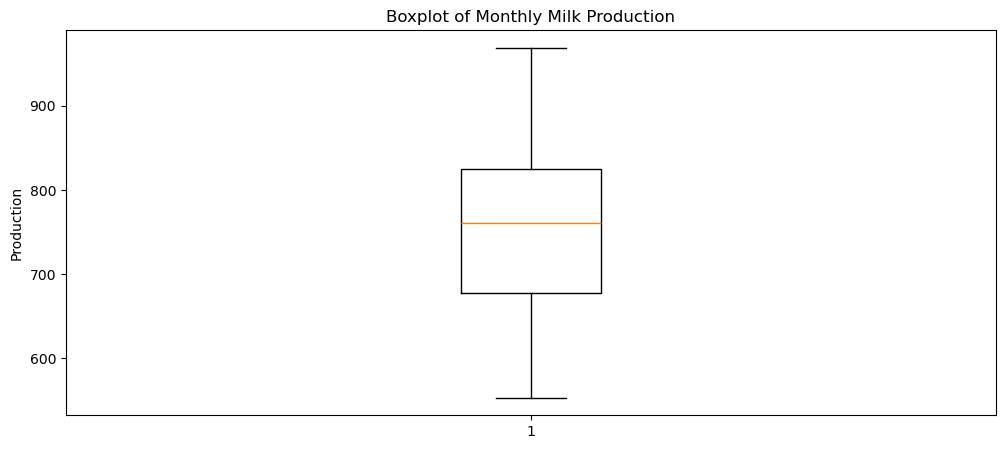

In [9]:
plt.figure(figsize=(12, 5))
plt.boxplot(df["Production"])
plt.title("Boxplot of Monthly Milk Production")
plt.ylabel("Production")
plt.show()

Exploratory Data Analysis

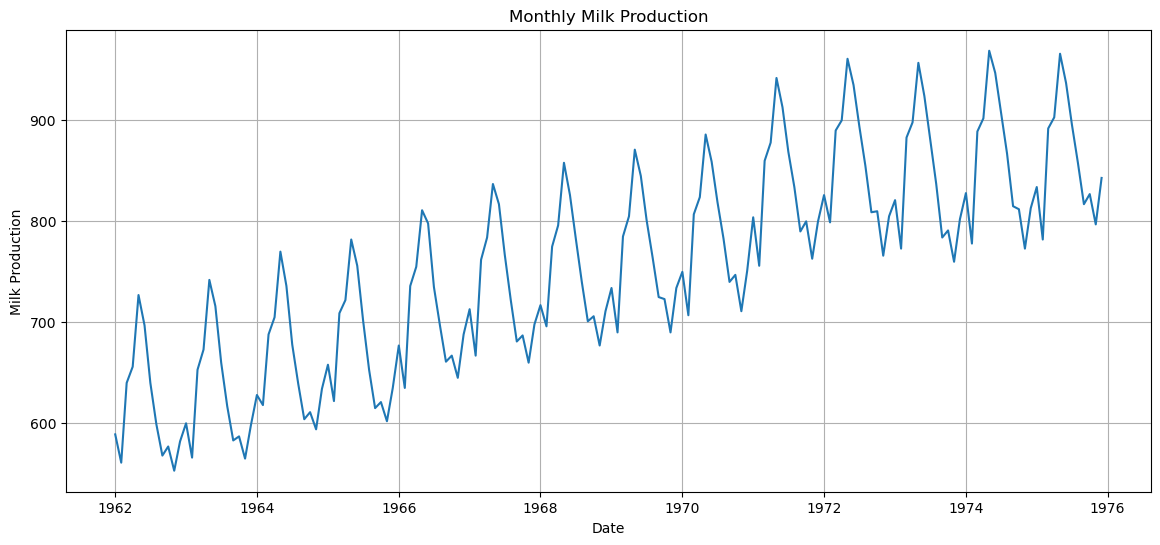

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Production"])
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

The time-series plot shows the changes in milk production over time.
The production values show an overall changing trend with seasonal fluctuations.

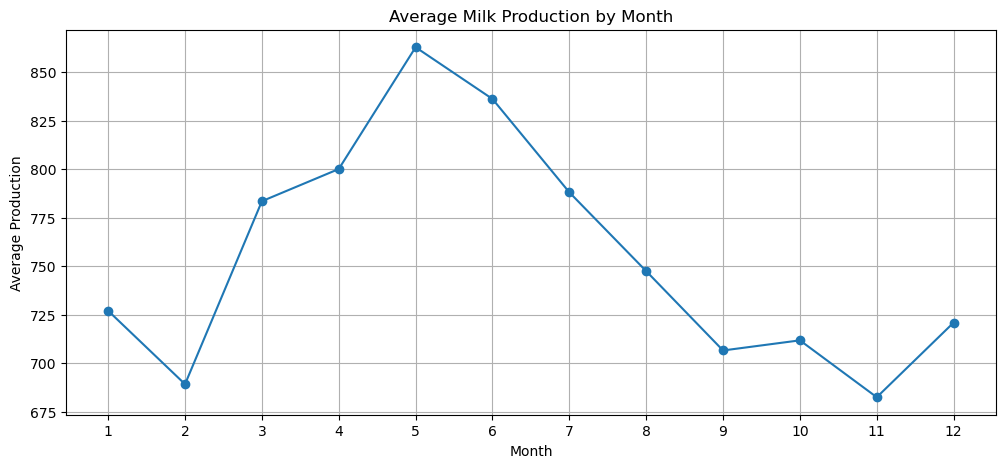

In [11]:
#analyze seasonality
plt.figure(figsize=(12, 5))
monthly_avg = df.groupby(df.index.month)["Production"].mean()
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.title("Average Milk Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

In [12]:
data = df[["Production"]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
print(scaled_data[:5])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [13]:
#create time-series sequence
window_size = 12
X = []
y = []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12)
y shape: (156,)


In [14]:
#reshape the data
X = X.reshape(X.shape[0], X.shape[1], 1)
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (156, 12, 1)
Final y shape: (156,)


In [15]:
#train test split
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)
X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]
print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

Training data: (109, 12, 1)
Validation data: (23, 12, 1)
Testing data: (24, 12, 1)


In [16]:
#build basic rnn model
rnn_model = Sequential([
    SimpleRNN(64, activation="tanh", input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
rnn_model.compile(
    optimizer="adam",
    loss="mse"
)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#train RNN model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.1741 - val_loss: 0.0311
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0491 - val_loss: 0.1219
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0217 - val_loss: 0.0195
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0206 - val_loss: 0.0384
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0122 - val_loss: 0.0180
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0100 - val_loss: 0.0101
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0076 - val_loss: 0.0048
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0088 - val_loss: 0.0070
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0077 - val_loss: 0.0042
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0056 - val_loss: 0.0036
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0077 - val_loss: 0.0037
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0054 - val_l

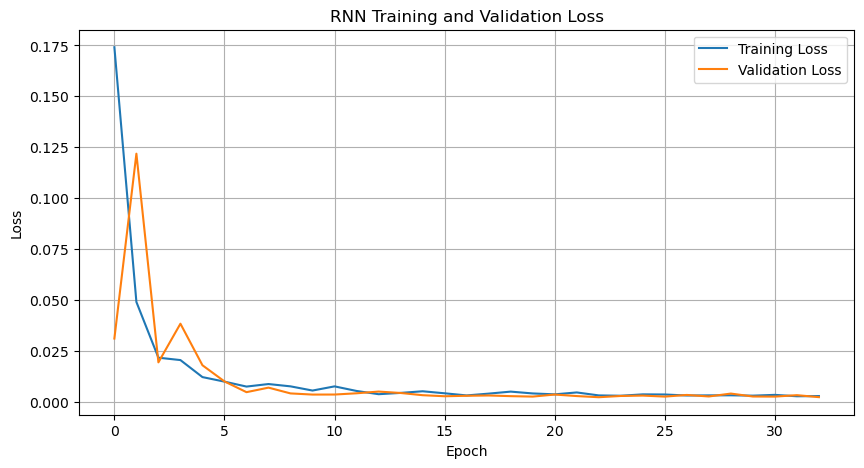

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history["loss"], label="Training Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")
plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
#build LSTMmodel
lstm_model = Sequential([
    LSTM(64, activation="tanh", input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - loss: 0.1443 - val_loss: 0.1677
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0448 - val_loss: 0.0244
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0324 - val_loss: 0.0252
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0251 - val_loss: 0.0334
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0261 - val_loss: 0.0369
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0225 - val_loss: 0.0248
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0244 - val_loss: 0.0242
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0226 - val_loss: 0.0260
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0232 - val_loss: 0.0243
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0238 - val_loss: 0.0258
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0218 - val_loss: 0.0235
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0194 - val_l

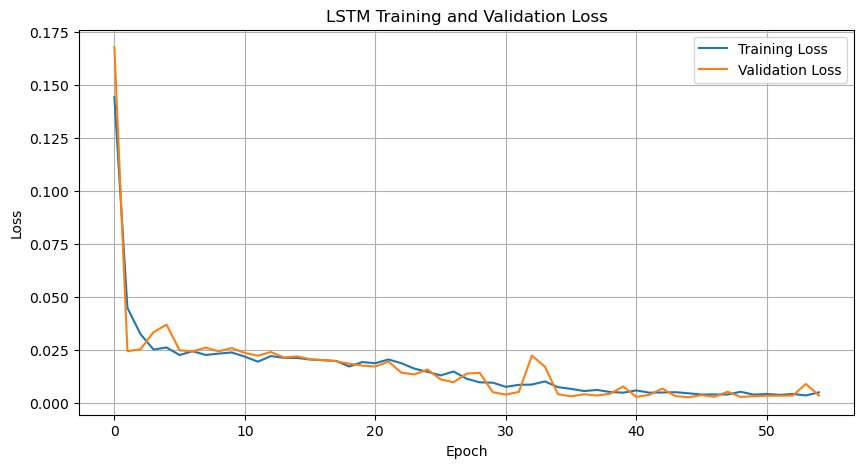

In [21]:
#LSTM Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
#Build GRU Model
gru_model = Sequential([
    GRU(64, activation="tanh", input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
gru_model.compile(
    optimizer="adam",
    loss="mse"
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#Train GRU model
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 0.2328 - val_loss: 0.3335
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0948 - val_loss: 0.1299
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0341 - val_loss: 0.0247
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0313 - val_loss: 0.0232
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0267 - val_loss: 0.0369
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0237 - val_loss: 0.0414
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0246 - val_loss: 0.0341
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0229 - val_loss: 0.0239
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0207 - val_loss: 0.0282
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0210 - val_loss: 0.0270
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0200 - val_loss: 0.0255
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0204 - val_l

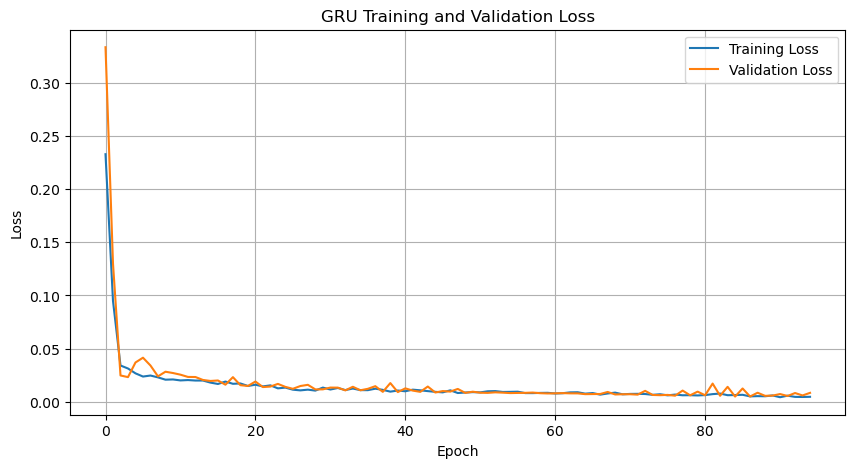

In [24]:
#GRU Loss Model
plt.figure(figsize=(10, 5))
plt.plot(gru_history.history["loss"], label="Training Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")
plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
#predictions
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step


In [26]:
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [27]:
#calculate RMSE ,MAE,MAPE
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100
    return mae, rmse, mape

In [28]:
#evaluation RNN 
rnn_mae, rnn_rmse, rnn_mape = evaluate_model(
    y_test_actual,
    rnn_pred
)
print("RNN Performance")
print("MAE :", rnn_mae)
print("RMSE:", rnn_rmse)
print("MAPE:", rnn_mape, "%")

RNN Performance
MAE : 12.723584493001292
RMSE: 15.434370649775685
MAPE: 1.4542347556623485 %


In [29]:
#evaluate LSTM
lstm_mae, lstm_rmse, lstm_mape = evaluate_model(
    y_test_actual,
    lstm_pred
)
print("LSTM Performance")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape, "%")

LSTM Performance
MAE : 19.372629801432282
RMSE: 22.96355653489561
MAPE: 2.2833339916747892 %


In [30]:
#Evaluate GRU
gru_mae, gru_rmse, gru_mape = evaluate_model(
    y_test_actual,
    gru_pred
)
print("GRU Performance")
print("MAE :", gru_mae)
print("RMSE:", gru_rmse)
print("MAPE:", gru_mape, "%")

GRU Performance
MAE : 26.491780598958325
RMSE: 33.07523464480542
MAPE: 3.138564797121352 %


In [31]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAPE": [rnn_mape, lstm_mape, gru_mape]
})
results

,Model,MAE,RMSE,MAPE
0,RNN,12.723584,15.434371,1.454235
1,LSTM,19.372630,22.963557,2.283334
2,GRU,26.491781,33.075235,3.138565


In [32]:
best_model = results.loc[results["RMSE"].idxmin(), "Model"]

print("Best Model based on RMSE:", best_model)

Best Model based on RMSE: RNN


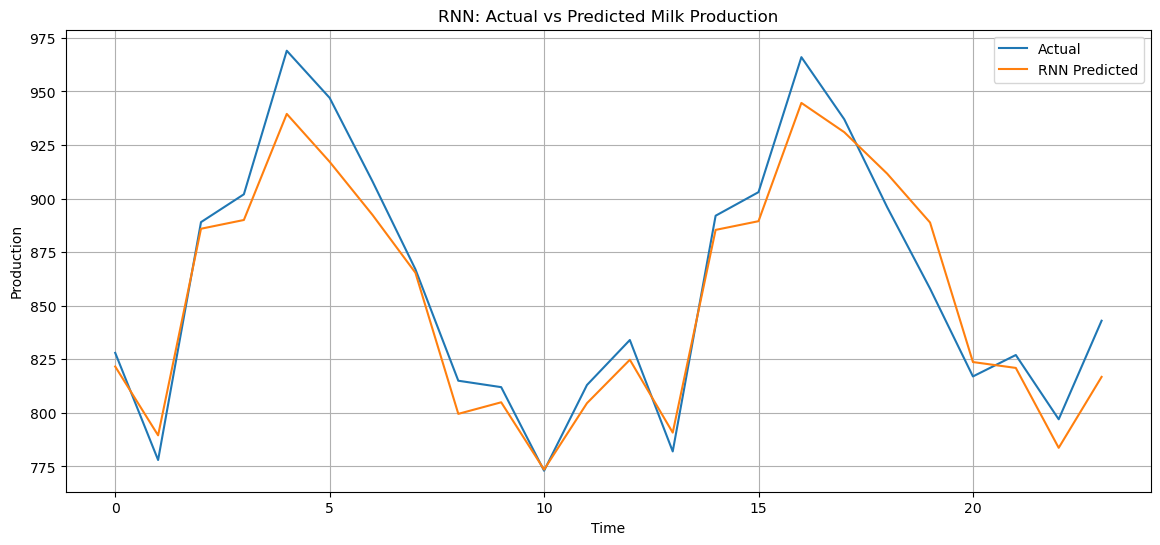

In [33]:
#Actual vs Predicted
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_pred, label="RNN Predicted")
plt.title("RNN: Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

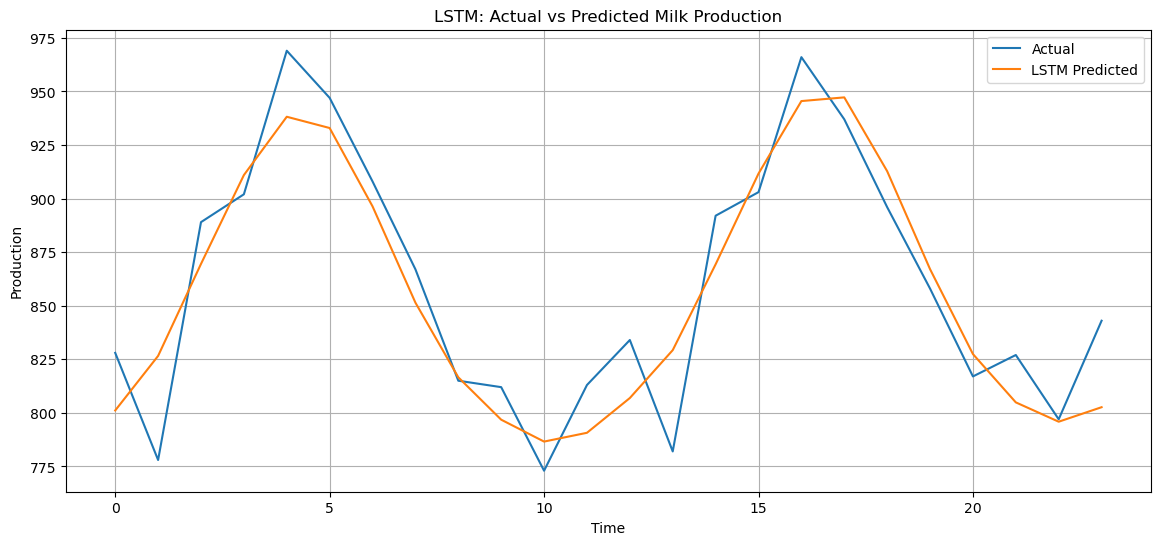

In [34]:
#Actual vs Predicted -LSTM
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label="Actual")
plt.plot(lstm_pred, label="LSTM Predicted")
plt.title("LSTM: Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

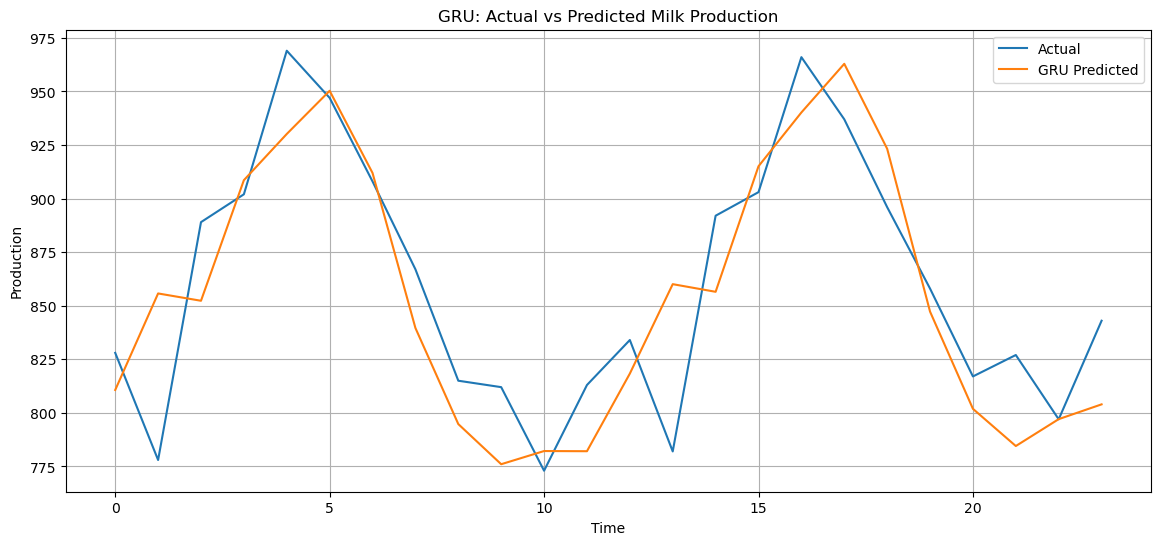

In [35]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label="Actual")
plt.plot(gru_pred, label="GRU Predicted")
plt.title("GRU: Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

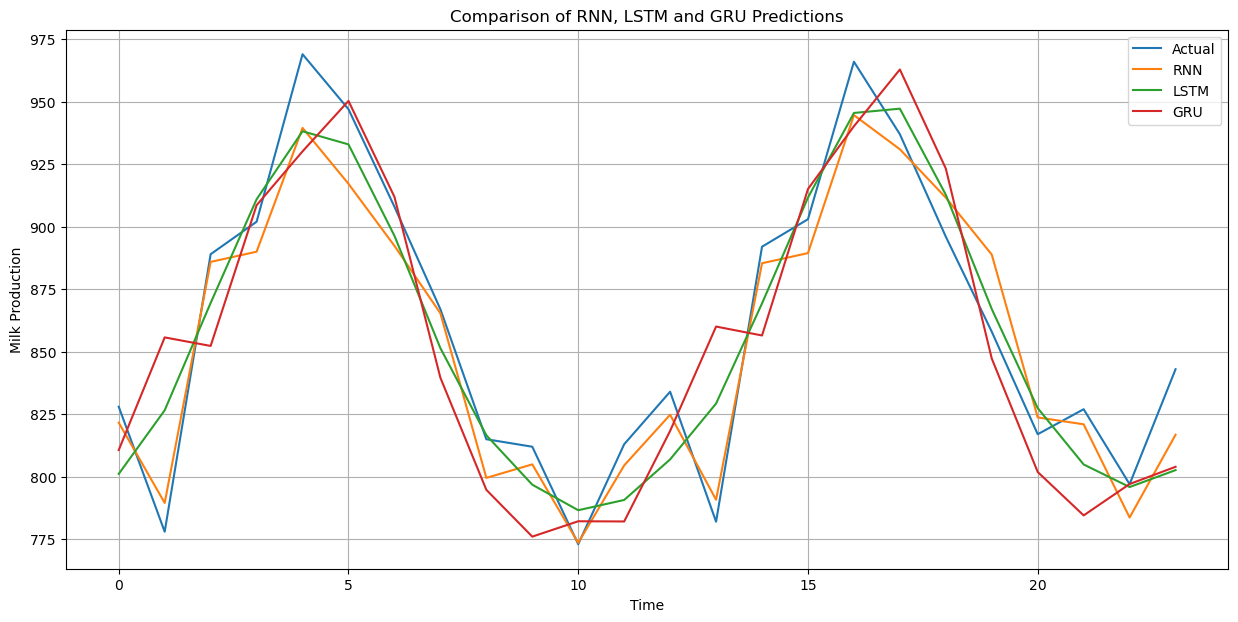

In [36]:
#Compare all three models Visually
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.title("Comparison of RNN, LSTM and GRU Predictions")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
#forecats
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}
best_model_obj = models[best_model]
print("Selected model:", best_model)

Selected model: RNN


In [38]:
last_sequence = scaled_data[-window_size:].reshape(1, window_size, 1)
future_predictions = []
for i in range(12):
    next_prediction = best_model_obj.predict(
        last_sequence,
        verbose=0
    )
    future_predictions.append(next_prediction[0, 0])
    last_sequence = np.append(
        last_sequence[:, 1:, :],
        next_prediction.reshape(1, 1, 1),
        axis=1
    )

In [39]:
#convert forecast back to orignal scale
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(
    future_predictions
)
future_predictions

array([[833.10657],
       [798.8848 ],
       [887.81354],
       [889.6293 ],
       [943.796  ],
       [925.22626],
       [904.7875 ],
       [878.27246],
       [828.2958 ],
       [839.19   ],
       [808.31104],
       [843.0094 ]], dtype=float32)

In [40]:
#create future dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Production": future_predictions.flatten()
})
forecast_df

,Date,Predicted Production
0,1976-01-01,833.106567
1,1976-02-01,798.884827
2,1976-03-01,887.813538
3,1976-04-01,889.629272
4,1976-05-01,943.796021
5,1976-06-01,925.226257
6,1976-07-01,904.787476
7,1976-08-01,878.272461
8,1976-09-01,828.295776
9,1976-10-01,839.190002


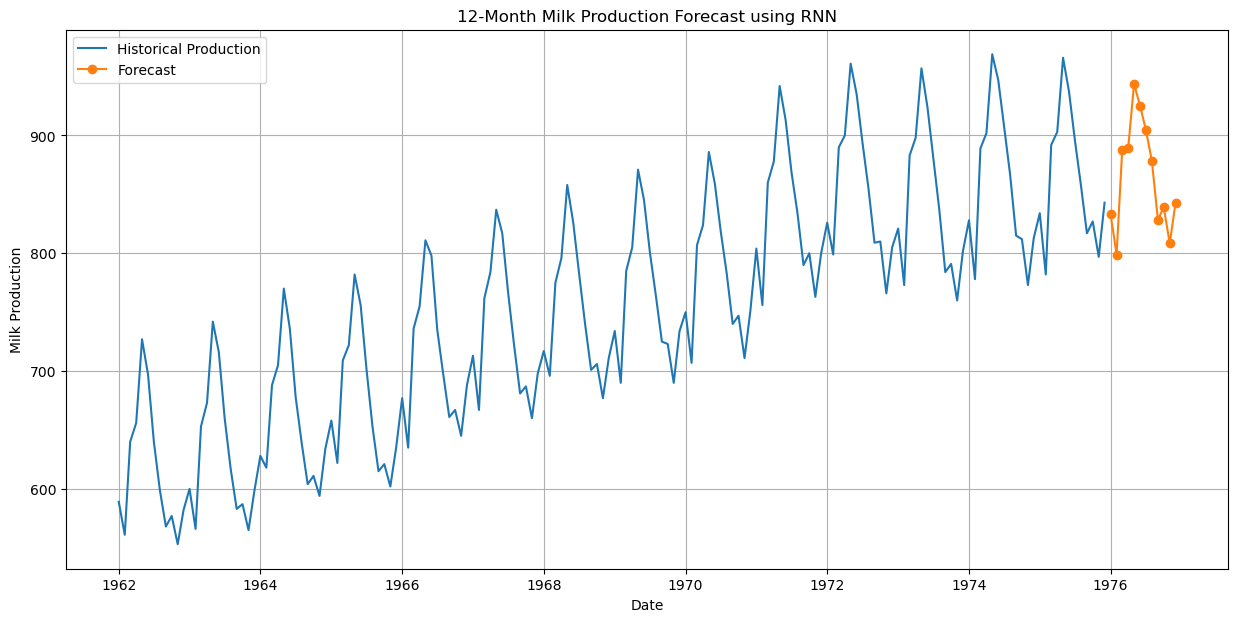

In [41]:
#visuaalize forecats
plt.figure(figsize=(15, 7))
plt.plot(
    df.index,
    df["Production"],
    label="Historical Production"
)
plt.plot(
    forecast_df["Date"],
    forecast_df["Predicted Production"],
    marker="o",
    label="Forecast"
)
plt.title(
    "12-Month Milk Production Forecast using " + best_model
)
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

Insights:

1. The forecasting models can help estimate future monthly milk production.

2. The predicted production can support supply-chain and distribution planning.

3. Forecasts can help the dairy business manage storage and inventory efficiently.

4. Expected seasonal changes can help management prepare resources in advance.

5. Workforce and operational activities can be planned according to expected production.

6. The model with the lowest RMSE, MAE and MAPE can be selected as the preferred forecasting model.

7. The 12-month forecast can support strategic planning and help reduce wastage.

Conclusion:

In this project, monthly milk production data was analyzed using deep-learning
time-series forecasting techniques. The data was explored, checked for missing
values and outliers, normalized, and converted into time-series sequences.

Three deep-learning models, namely RNN, LSTM and GRU, were developed and trained.
Their performance was evaluated using MAE, RMSE and MAPE.

The models were compared based on their forecasting errors, and the model with
the lowest RMSE was selected as the best-performing model. Finally, the selected
model was used to forecast milk production for the next 12 months.

These forecasts can help a dairy business improve production planning, inventory
management, resource allocation and supply-chain decisions.